In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/training_level1_full.csv")
df.head()



,player_id,season,salary_usd,log_salary,salary_cap,salary_cap_ratio,log_salary_cap_ratio,salary_cap_equiv,Age,GP,...,award_NBA Eastern Conference Finals MVP,award_NBA Western Conference Finals MVP,award_Rookie of the Year,award_Sixth Man of the Year,award_Twyman-Stokes Teammate of the Year Award,award_total,injury_events,injury_unique_dates,injury_unique_categories,injury_any
0,1,2020,43006362.0,17.576859,109140000.0,0.394048,0.332212,5.539837e+07,33,63,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2,2020,28751775.0,17.174210,109140000.0,0.263439,0.233838,3.703642e+07,28,60,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,3,2020,31626953.0,17.269520,109140000.0,0.289783,0.254474,4.074006e+07,30,67,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,4,2020,29542010.0,17.201324,109140000.0,0.270680,0.239552,3.805435e+07,27,51,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,5,2020,27528090.0,17.130718,109140000.0,0.252227,0.224924,3.546013e+07,26,61,...,0.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0,1.0,True


In [4]:
print("Shape:", df.shape)

print("\nMissing ratio top20:")
print(df.isna().mean().sort_values(ascending=False).head(20))

dups = df.duplicated(subset=["player_id", "season"]).sum()
print("\nDuplicates by (player_id, season):", dups)



Shape: (2082, 132)

Missing ratio top20:
overall_pick             0.159942
draft_is_second_round    0.159942
draft_year               0.159942
years_since_draft        0.159942
draft_is_lottery         0.159942
round                    0.159942
round_pick               0.159942
draft_is_first_round     0.159942
log_salary               0.000000
salary_usd               0.000000
season                   0.000000
player_id                0.000000
salary_cap               0.000000
salary_cap_ratio         0.000000
log_salary_cap_ratio     0.000000
salary_cap_equiv         0.000000
Age                      0.000000
GP                       0.000000
W                        0.000000
L                        0.000000
dtype: float64

Duplicates by (player_id, season): 0


Text(0.5, 1.0, 'Count by season')

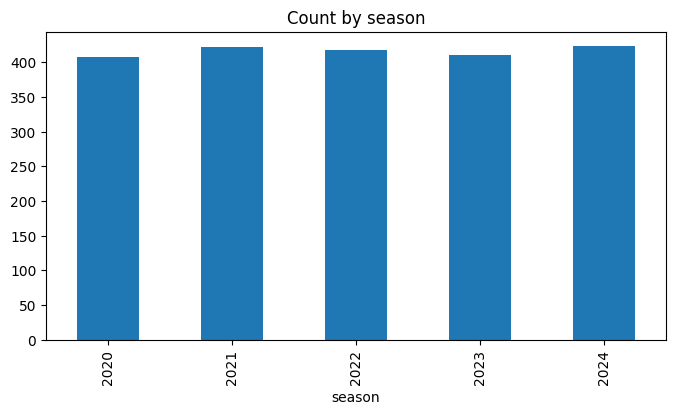

In [5]:
df["season"].value_counts().sort_index().plot(kind="bar", figsize=(8,4))
plt.title("Count by season")


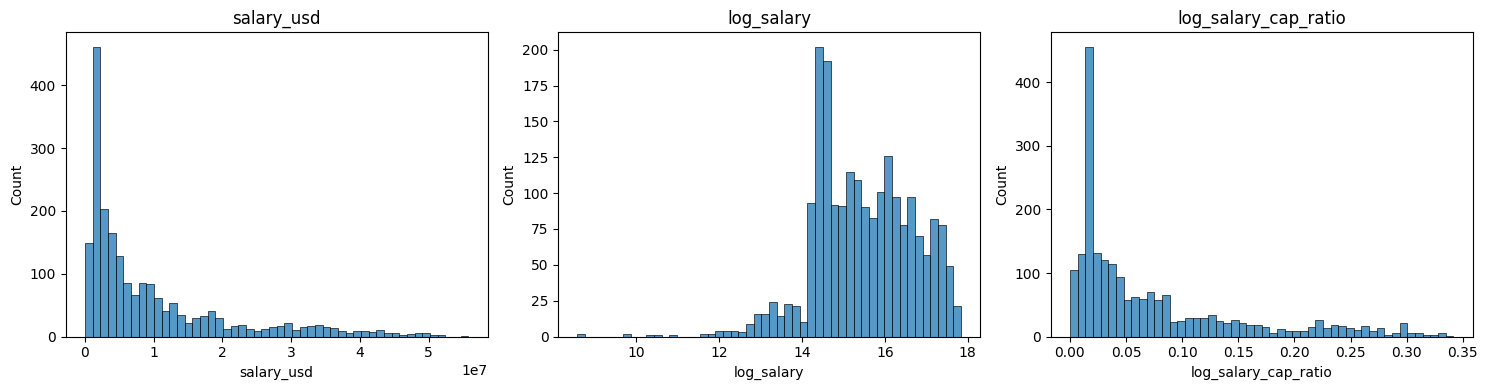

In [6]:
fig, ax = plt.subplots(1,3, figsize=(15,4))

sns.histplot(df["salary_usd"], bins=50, ax=ax[0])
ax[0].set_title("salary_usd")

sns.histplot(df["log_salary"], bins=50, ax=ax[1])
ax[1].set_title("log_salary")

sns.histplot(df["log_salary_cap_ratio"], bins=50, ax=ax[2])
ax[2].set_title("log_salary_cap_ratio")

plt.tight_layout()

Text(0.5, 1.0, 'Median salary by season')

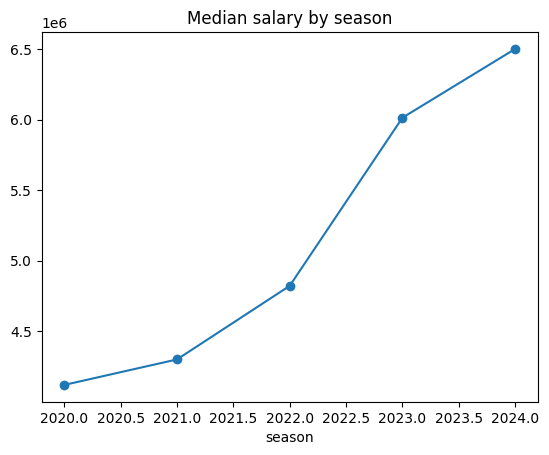

In [7]:
df.groupby("season")["salary_usd"].median().plot(kind="line", marker="o")
plt.title("Median salary by season")


Text(0.5, 1.0, 'Correlation heatmap (first 50)')

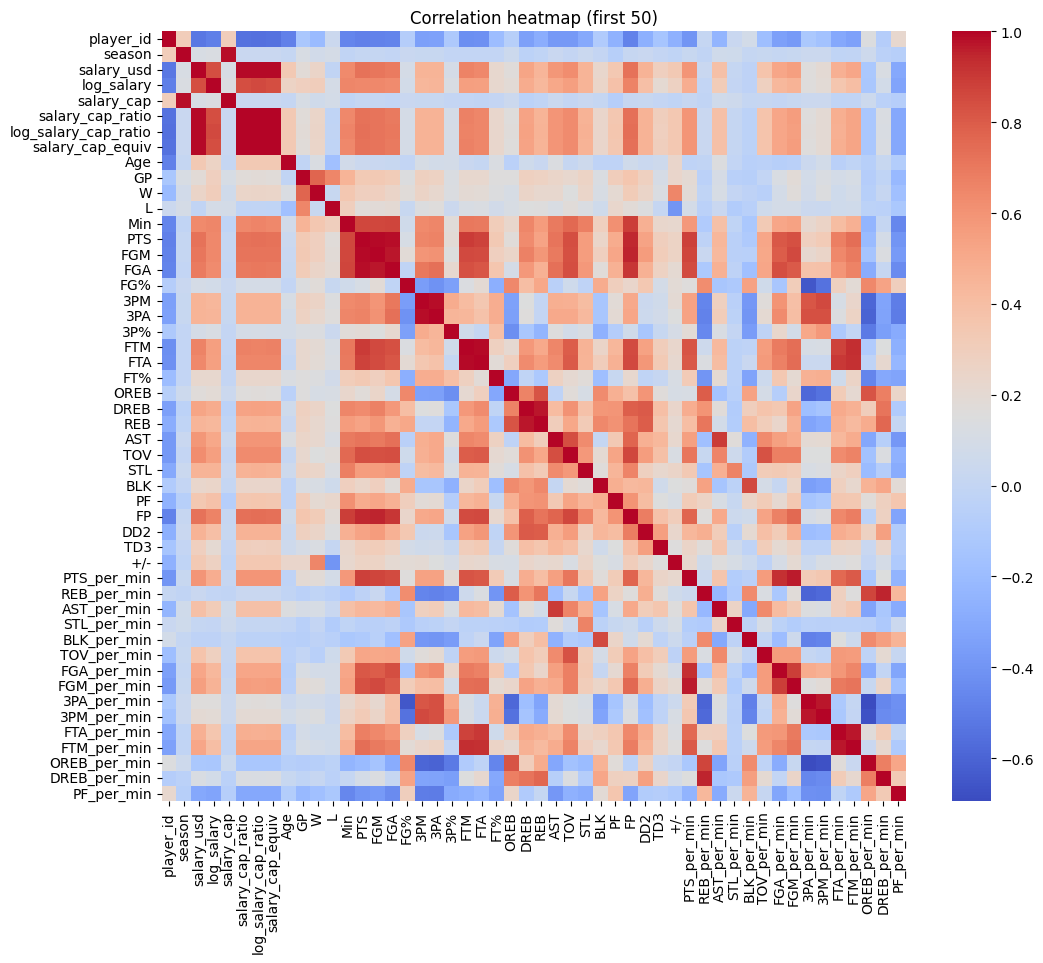

In [8]:
numeric_cols = df.select_dtypes("number").columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr.head(50).iloc[:50, :50], cmap="coolwarm")
plt.title("Correlation heatmap (first 50)")
